In [1]:
import pandas as pd 
import numpy as np
import os 
import glob as glob
import matplotlib.pyplot as plt

#### Bergmann Hommens posthoc with Friedman 0.05

In [2]:
path = 'critical_diff/BOTH_51020p_shd_525/res/'
metric = 'DHD'
bergmann_psthoc = pd.read_csv(path+f'{metric}_bergmann_hommel.csv', index_col = 0)
bergmann_psthoc.fillna(1, inplace=True)
cols = bergmann_psthoc.columns
newcols = [col.replace('.','-') for col in cols]
bergmann_psthoc.columns = newcols
bergmann_psthoc.index = newcols
bergmann_psthoc

,HC,HC-TL,PC-stable,PCS-TL
HC,1.000000,0.040067,0.021072,0.853514
HC-TL,0.040067,1.000000,0.000004,0.040067
PC-stable,0.021072,0.000004,1.000000,0.024073
PCS-TL,0.853514,0.040067,0.024073,1.000000


In [3]:
avg_rank = pd.read_csv(path+f'{metric}_avg_ranking.csv',index_col = 0)
avg_rank.sort_values(by='average.ranking', inplace=True)
avg_rank = avg_rank['average.ranking']
index = avg_rank.index
newindex = [col.replace('.','-') for col in index]
avg_rank.index = newindex
# avg_rank.index = newcols
avg_rank

HC-TL        1.900000
HC           2.463636
PCS-TL       2.509091
PC-stable    3.127273
Name: average.ranking, dtype: float64

In [4]:
bergmann_psthoc

,HC,HC-TL,PC-stable,PCS-TL
HC,1.000000,0.040067,0.021072,0.853514
HC-TL,0.040067,1.000000,0.000004,0.040067
PC-stable,0.021072,0.000004,1.000000,0.024073
PCS-TL,0.853514,0.040067,0.024073,1.000000


In [5]:
# Optional: nicer p-value formatting (shows '<.001' for very small values)
def format_pval(x):
    if pd.isna(x):
        return ''
    elif x < 0.001:
        return f'{x:.2e}' 
    elif x < 0.01:
        return f'{x:.2e}' 
    elif x < 0.05:
        return f'{x:.2e}'  
    else:
        return f'{x:.2e}'
# Create annotation DataFrame (strings, empty on diagonal/NaN)
annot_df = bergmann_psthoc.applymap(format_pval)

/tmp/ipykernel_2936/237719950.py:14: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_df = bergmann_psthoc.applymap(format_pval)


/tmp/ipykernel_2936/99625014.py:27: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/home/rsojo/anaconda3/envs/pybnesianFT/lib/python3.9/site-packages/numpy/core/fromnumeric.py:59: FutureWarning: 'Series.swapaxes' is deprecated and will be removed in a future version. Please use 'Series.transpose' instead.
  return bound(*args, **kwds)


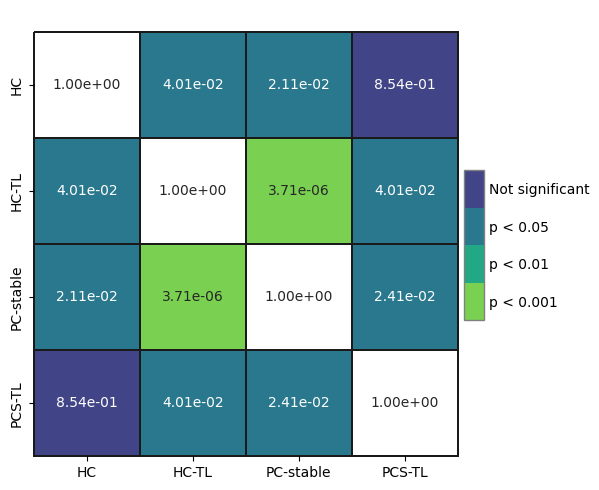

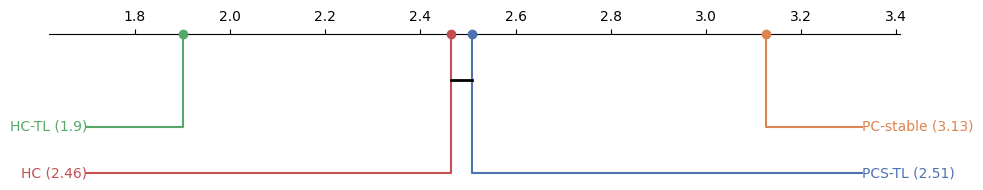

In [6]:
import scikit_posthocs as sp
import seaborn as sns
plt.figure(figsize=(5, 5))
plt.title('Significance Heatmap')

# Format: diagonal, non-significant, p<0.001, p<0.01, p<0.05
cmap = ['1', '#414487ff', '#7ad151ff' , '#22a884ff','#2a788eff' ]
heatmap_args = {'labels':True,'linewidths': 0.25, 'linecolor': '0.1', 'clip_on': False, 
                'square': True, 'cbar_ax_bbox': [0.96, 0.35, 0.04, 0.3], 'cmap': cmap, 'annot': 
                annot_df.values, 'fmt':''}
cmap2 = sns.color_palette("deep")
color_mapping = {
    'PCS-TL': cmap2[0],          # blue
    'PC-stable': cmap2[1],          # orange
    'HC-TL': cmap2[2],   # green
    'HC': cmap2[3],     # red
}

# Define label properties with corresponding colors
label_props = {model: {'color': color} for model, color in color_mapping.items()}

ax, cbar = sp.sign_plot(bergmann_psthoc, **heatmap_args, flat=False)
ax.set_title(' ')
# Customize colorbar labels
cbar.set_ticks([3,0,1, 2])
cbar.set_ticklabels(['Not significant', 'p < 0.001', 'p < 0.01', 'p < 0.05'])
plt.tight_layout()

plt.savefig(path+f'{metric}_significanceHM.pdf',format='pdf', bbox_inches="tight")

plt.figure(figsize=(10, 2), dpi=100)
# plt.title('Critical difference diagram of average score ranks')
sp.critical_difference_diagram(avg_rank, 
                               bergmann_psthoc,
                               text_h_margin=0.2,
                               color_palette=color_mapping,
                               label_fmt_right = '{label} ({rank:.3g})',
                               label_fmt_left = '{label} ({rank:.3g})',
                               #label_props=label_props,#{'color': 'black', 'fontweight': None},
                                #crossbar_props={'color': 'black', 'marker': None},
                                #marker_props={'marker': '', 's': 50, 'color': 'k', 'edgecolor': 'k'},
                               # elbow_props={'color': '#3a3b3c'},
                               )
plt.tight_layout()
plt.savefig(path+f'{metric}_CDD_bergmann.pdf',format='pdf', bbox_inches="tight")